INSTALAN

In [ ]:
print ("Instal torch")
!pip install transformers datasets torch
print ("Instal NLTK")
!pip install nltk
print ("Instal Sastrawi")
!pip install Sastrawi

Instal torch
Instal NLTK
Instal Sastrawi
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.5 MB/s eta 0:00:00


SCRAPING UNAIR NEWS

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

#URL halaman utama kategori berita
BASE_URL = "https://unair.ac.id/category/berita/"
jumlah_artikel = 113

def get_article_links(base_url, jumlah_artikel, max_pages=800):
    print("[INFO] Mengambil daftar link artikel...")
    links = []
    current_page = 1

    while len(links) < jumlah_artikel and current_page <= max_pages:
        # Bangun URL sesuai format halaman UNAIR
        page_url = base_url if current_page == 1 else f"{base_url}page/{current_page}/"
        print(f"[INFO] Membuka halaman: {page_url}")

        r = requests.get(page_url)
        if r.status_code != 200:
            print(f"[WARNING] Halaman {current_page} tidak bisa dibuka (status {r.status_code}), stop.")
            break

        soup = BeautifulSoup(r.text, "html.parser")

        #Ambil semua artikel di halaman ini
        articles = soup.select("article.elementor-post")
        print(f"[INFO] Ditemukan {len(articles)} artikel di halaman {current_page}")

        if not articles:
            print("[INFO] Tidak ada artikel lagi, berhenti.")
            break

        for art in articles:
            link = art.find("a", href=True)["href"]
            if link not in links:  #hindari duplikat
                links.append(link)
                print(f"   -> Link ditemukan: {link}")
            if len(links) >= jumlah_artikel:
                print("[INFO] Batas link tercapai")
                return links

        current_page += 1  # lanjut ke halaman berikutnya

    return links


def scrape_article(url):
    print(f"[SCRAPING] Memproses artikel: {url}")
    r = requests.get(url)
    soup = BeautifulSoup(r.text, "html.parser")

    # Judul
    title_tag = soup.select_one("h1.entry-title, h2.elementor-heading-title")
    title = title_tag.get_text(strip=True) if title_tag else ""
    print(f"   Judul: {title}")

    # Tanggal / Tahun
    date_tag = soup.select_one(".elementor-post-info__item--type-date time")
    date = date_tag.get_text(strip=True) if date_tag else ""
    year = ""
    if date:
        # ambil 4 digit terakhir jika ada tahun
        import re
        match = re.search(r"\b(20\d{2})\b", date)
        year = match.group(1) if match else ""
    print(f"   Tanggal: {date}, Tahun: {year}")

    # Jam (optional)
    time_tag = soup.select_one(".elementor-post-info__item--type-time time")
    time_str = time_tag.get_text(strip=True) if time_tag else ""

    # Isi berita (gabungkan p, h4, h5, h6)
    content_parts = soup.select("div.elementor-widget-theme-post-content p, \
                                 div.elementor-widget-theme-post-content h4, \
                                 div.elementor-widget-theme-post-content h5, \
                                 div.elementor-widget-theme-post-content h6")
    content = "\n".join([c.get_text(" ", strip=True) for c in content_parts])
    print(f"   Isi berita panjang: {len(content)} karakter")

    # Penulis
    author = ""
    editor = ""
    for p in soup.select("p"):
        txt = p.get_text(strip=True)
        if txt.startswith("Penulis:"):
            author = txt.replace("Penulis:", "").strip()
        elif txt.startswith("Editor:"):
            editor = txt.replace("Editor:", "").strip()

    print(f"   Penulis: {author}, Editor: {editor}")


    # Kategori
    category_tags = soup.select(".elementor-post-info__terms-list-item")
    categories = ", ".join([c.get_text(strip=True) for c in category_tags]) if category_tags else ""
    print(f"   Kategori: {categories}")

    return {
        "Judul": title,
        "Isi Berita": content,
        "Tanggal": date,
        "Tahun": year,
        "Jam": time_str,
        "Penulis": author,
        "Editor": editor,
        "Kategori": categories,
        "Link": url
    }

if __name__ == "__main__":
    print("[START] Proses scraping dimulai...")

    # 1. Ambil link artikel
    article_links = get_article_links(BASE_URL, jumlah_artikel)
    print(f"[INFO] Total link terkumpul: {len(article_links)}")

    # 2. Scrape tiap artikel
    data = []
    for link in article_links:
        artikel = scrape_article(link)
        data.append(artikel)
        print("[DONE] Artikel berhasil disimpan!\n")

    # 3. Simpan ke DataFrame
    print("[INFO] Membuat DataFrame...")
    df = pd.DataFrame(data)

    # 4. Urutkan berdasarkan tanggal terbaru → terlama
    print("[INFO] Mengurutkan data berdasarkan tanggal...")
    df["Tanggal"] = pd.to_datetime(df["Tanggal"], errors="coerce")
    df = df.sort_values("Tanggal", ascending=False)

    # 5. Simpan ke CSV & Excel
    print("[INFO] Menyimpan ke unair_news.csv dan unair_news.xlsx...")
    df.to_csv("unair_news.csv", index=False, encoding="utf-8-sig")
    df.to_excel("unair_news.xlsx", index=False)

    print("[FINISH] Scraping selesai. Data tersimpan di unair_news.csv dan unair_news.xlsx")

[START] Proses scraping dimulai...
[INFO] Mengambil daftar link artikel...
[INFO] Membuka halaman: https://unair.ac.id/category/berita/
[INFO] Ditemukan 12 artikel di halaman 1
   -> Link ditemukan: https://unair.ac.id/ika-unair-tegaskan-gelar-akademik-adalah-amanah-untuk-berkarya-dan-mengabdi/
   -> Link ditemukan: https://unair.ac.id/cuankruk-3-ajak-mahasiswa-feb-unair-kuasai-marketing-dan-kembangkan-bisnis/
   -> Link ditemukan: https://unair.ac.id/glad2glow-goes-to-campus-beri-inspirasi-personal-branding-dan-make-up/
   -> Link ditemukan: https://unair.ac.id/wujudkan-kkn-bbk-berbasis-sdgs-lpmb-unair-selenggarakan-tot-dpl/
   -> Link ditemukan: https://unair.ac.id/isoph-icoeph-2025-angkat-isu-kesehatan-global-dari-game-edukasi-hingga-kesehatan-perempuan/
   -> Link ditemukan: https://unair.ac.id/banking-101-dpkka-unair-bekali-mahasiswa-literasi-finansial-sejak-dini/
   -> Link ditemukan: https://unair.ac.id/unair-gelar-road-to-traffic-safety-champion-mahasiswa-didorong-jadi-pelopor-

NLP

Ambil teks yang dibutuhkan

In [ ]:
import pandas as pd

#Baca Path CSV
df = pd.read_csv(f'/content/unair_news.csv')

#Ambil Judul dan Isi Berita
df= df[["Judul", "Isi Berita"]]

#Tampilkan contoh 5 baris pertama
print(df.head())

                                               Judul  \
0  IKA UNAIR Tegaskan Gelar Akademik Adalah Amana...   
1  Glad2Glow Goes to Campus Beri Inspirasi Person...   
2  Cuankruk 3, Ajak Mahasiswa FEB UNAIR Kuasai Ma...   
3  Wujudkan KKN BBK Berbasis SDGs, LPMB UNAIR Sel...   
4  Banking 101 DPKKA UNAIR, Bekali Mahasiswa Lite...   

                                          Isi Berita  
0  UNAIR NEWS – Wisuda Universitas Airlangga (UNA...  
1  UNAIR NEWS – Badan Eksekutif Mahasiswa (BEM) F...  
2  UNAIR NEWS – Badan Eksekutif Mahasiswa (BEM) F...  
3  UNAIR NEWS – Universitas Airlangga ( UNAIR ) m...  
4  UNAIR NEWS – Direktorat Pengembangan Karir, In...  


Pre-processing

Cleaning

In [ ]:
import re

def cleanResume(txt):
    cleantxt = re.sub(r'http\S+\s', ' ', txt)
    cleantxt = re.sub(r'RT|cc', ' ', cleantxt)
    cleantxt = re.sub(r'@\S+', ' ', cleantxt)
    cleantxt = re.sub(r'#\S+', ' ', cleantxt)
    cleantxt = re.sub(r'^UNAIR NEWS –', '', cleantxt)
    cleantxt = re.sub(r'[%s]' % re.escape("!\"#$%&'()*+,-./:;<=>?@[\\]^_`{|}~ "), ' ', cleantxt)
    cleantxt = re.sub(r'[^\x00-\x7f]', ' ', cleantxt)
    cleantxt = re.sub(r'\s+', ' ', cleantxt)
    return cleantxt

df['Isi Berita'] = df['Isi Berita'].apply(lambda x: cleanResume(x))
display(df.head())

,Judul,Isi Berita
0,IKA UNAIR Tegaskan Gelar Akademik Adalah Amana...,Wisuda Universitas Airlangga UNAIR ke 254 pad...
1,Glad2Glow Goes to Campus Beri Inspirasi Person...,Badan Eksekutif Mahasiswa BEM Fakultas Ekonom...
2,"Cuankruk 3, Ajak Mahasiswa FEB UNAIR Kuasai Ma...",Badan Eksekutif Mahasiswa BEM Fakultas Ekonom...
3,"Wujudkan KKN BBK Berbasis SDGs, LPMB UNAIR Sel...",Universitas Airlangga UNAIR melalui Lembaga P...
4,"Banking 101 DPKKA UNAIR, Bekali Mahasiswa Lite...",Direktorat Pengembangan Karir Inkubasi Kewira...


Gabung Judul dan Isi Berita

In [ ]:
#Gabung Judul dan Isi Berita
df['Berita'] = df['Judul'] + ': ' + df['Isi Berita']
df.head()

,Judul,Isi Berita,Berita
0,IKA UNAIR Tegaskan Gelar Akademik Adalah Amana...,Wisuda Universitas Airlangga UNAIR ke 254 pad...,IKA UNAIR Tegaskan Gelar Akademik Adalah Amana...
1,Glad2Glow Goes to Campus Beri Inspirasi Person...,Badan Eksekutif Mahasiswa BEM Fakultas Ekonom...,Glad2Glow Goes to Campus Beri Inspirasi Person...
2,"Cuankruk 3, Ajak Mahasiswa FEB UNAIR Kuasai Ma...",Badan Eksekutif Mahasiswa BEM Fakultas Ekonom...,"Cuankruk 3, Ajak Mahasiswa FEB UNAIR Kuasai Ma..."
3,"Wujudkan KKN BBK Berbasis SDGs, LPMB UNAIR Sel...",Universitas Airlangga UNAIR melalui Lembaga P...,"Wujudkan KKN BBK Berbasis SDGs, LPMB UNAIR Sel..."
4,"Banking 101 DPKKA UNAIR, Bekali Mahasiswa Lite...",Direktorat Pengembangan Karir Inkubasi Kewira...,"Banking 101 DPKKA UNAIR, Bekali Mahasiswa Lite..."


Case folding

In [ ]:
#Case folding: ubah semua huruf pada kolom 'Berita' menjadi huruf kecil
df['Berita_preprocessed'] = df['Berita'].str.lower()

#Tampilkan 5 baris pertama setelah case folding
df.head()

,Judul,Isi Berita,Berita,Berita_preprocessed
0,IKA UNAIR Tegaskan Gelar Akademik Adalah Amana...,Wisuda Universitas Airlangga UNAIR ke 254 pad...,IKA UNAIR Tegaskan Gelar Akademik Adalah Amana...,ika unair tegaskan gelar akademik adalah amana...
1,Glad2Glow Goes to Campus Beri Inspirasi Person...,Badan Eksekutif Mahasiswa BEM Fakultas Ekonom...,Glad2Glow Goes to Campus Beri Inspirasi Person...,glad2glow goes to campus beri inspirasi person...
2,"Cuankruk 3, Ajak Mahasiswa FEB UNAIR Kuasai Ma...",Badan Eksekutif Mahasiswa BEM Fakultas Ekonom...,"Cuankruk 3, Ajak Mahasiswa FEB UNAIR Kuasai Ma...","cuankruk 3, ajak mahasiswa feb unair kuasai ma..."
3,"Wujudkan KKN BBK Berbasis SDGs, LPMB UNAIR Sel...",Universitas Airlangga UNAIR melalui Lembaga P...,"Wujudkan KKN BBK Berbasis SDGs, LPMB UNAIR Sel...","wujudkan kkn bbk berbasis sdgs, lpmb unair sel..."
4,"Banking 101 DPKKA UNAIR, Bekali Mahasiswa Lite...",Direktorat Pengembangan Karir Inkubasi Kewira...,"Banking 101 DPKKA UNAIR, Bekali Mahasiswa Lite...","banking 101 dpkka unair, bekali mahasiswa lite..."


Tokenized

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

from nltk.tokenize import word_tokenize
#Tokenisasi: memecahkan kalimat menjadi token/kata
df['Berita_preprocessed'] = df['Berita_preprocessed'].apply(word_tokenize)

#Tampilkan 5 baris pertama hasil tokenisasi
df.head()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,Judul,Isi Berita,Berita,Berita_preprocessed
0,IKA UNAIR Tegaskan Gelar Akademik Adalah Amana...,Wisuda Universitas Airlangga UNAIR ke 254 pad...,IKA UNAIR Tegaskan Gelar Akademik Adalah Amana...,"[ika, unair, tegaskan, gelar, akademik, adalah..."
1,Glad2Glow Goes to Campus Beri Inspirasi Person...,Badan Eksekutif Mahasiswa BEM Fakultas Ekonom...,Glad2Glow Goes to Campus Beri Inspirasi Person...,"[glad2glow, goes, to, campus, beri, inspirasi,..."
2,"Cuankruk 3, Ajak Mahasiswa FEB UNAIR Kuasai Ma...",Badan Eksekutif Mahasiswa BEM Fakultas Ekonom...,"Cuankruk 3, Ajak Mahasiswa FEB UNAIR Kuasai Ma...","[cuankruk, 3, ,, ajak, mahasiswa, feb, unair, ..."
3,"Wujudkan KKN BBK Berbasis SDGs, LPMB UNAIR Sel...",Universitas Airlangga UNAIR melalui Lembaga P...,"Wujudkan KKN BBK Berbasis SDGs, LPMB UNAIR Sel...","[wujudkan, kkn, bbk, berbasis, sdgs, ,, lpmb, ..."
4,"Banking 101 DPKKA UNAIR, Bekali Mahasiswa Lite...",Direktorat Pengembangan Karir Inkubasi Kewira...,"Banking 101 DPKKA UNAIR, Bekali Mahasiswa Lite...","[banking, 101, dpkka, unair, ,, bekali, mahasi..."


Stopwords

In [ ]:
#Import dan download stopwords resource
import nltk
nltk.download('stopwords')

#Import stopwords dari NLTK
from nltk.corpus import stopwords

#Stopwords berbahasa Indonesia
stopwords = stopwords.words('indonesian')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
#Stopword removal: menghapus kata-kata umum dan non-alfabet
df['Berita_preprocessed'] = df['Berita_preprocessed'].apply(
    lambda tokens: [word for word in tokens if word.isalpha() and word not in stopwords]
)
#Tampilkan hasil pertama setelah stopword removal
df.head()

,Judul,Isi Berita,Berita,Berita_preprocessed
0,IKA UNAIR Tegaskan Gelar Akademik Adalah Amana...,Wisuda Universitas Airlangga UNAIR ke 254 pad...,IKA UNAIR Tegaskan Gelar Akademik Adalah Amana...,"[ika, unair, tegaskan, gelar, akademik, amanah..."
1,Glad2Glow Goes to Campus Beri Inspirasi Person...,Badan Eksekutif Mahasiswa BEM Fakultas Ekonom...,Glad2Glow Goes to Campus Beri Inspirasi Person...,"[goes, to, campus, inspirasi, personal, brandi..."
2,"Cuankruk 3, Ajak Mahasiswa FEB UNAIR Kuasai Ma...",Badan Eksekutif Mahasiswa BEM Fakultas Ekonom...,"Cuankruk 3, Ajak Mahasiswa FEB UNAIR Kuasai Ma...","[cuankruk, ajak, mahasiswa, feb, unair, kuasai..."
3,"Wujudkan KKN BBK Berbasis SDGs, LPMB UNAIR Sel...",Universitas Airlangga UNAIR melalui Lembaga P...,"Wujudkan KKN BBK Berbasis SDGs, LPMB UNAIR Sel...","[wujudkan, kkn, bbk, berbasis, sdgs, lpmb, una..."
4,"Banking 101 DPKKA UNAIR, Bekali Mahasiswa Lite...",Direktorat Pengembangan Karir Inkubasi Kewira...,"Banking 101 DPKKA UNAIR, Bekali Mahasiswa Lite...","[banking, dpkka, unair, bekali, mahasiswa, lit..."


Stemming

In [ ]:
#Import dan download Sastrawi
!pip install Sastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

#Buat stemmer dari Sastrawi
factory = StemmerFactory()
stemmer = factory.create_stemmer()

In [ ]:
#Terapkan stemming ke setiap daftar token di kolom 'Berita_Preprocessed'
df['Berita_preprocessed'] = df['Berita_preprocessed'].apply(lambda tokens: [stemmer.stem(token) for token in tokens])

#Tampilkan hasil pertama setelah stemming
df.head()

,Judul,Isi Berita,Berita,Berita_preprocessed
0,IKA UNAIR Tegaskan Gelar Akademik Adalah Amana...,Wisuda Universitas Airlangga UNAIR ke 254 pad...,IKA UNAIR Tegaskan Gelar Akademik Adalah Amana...,"[ika, unair, tegas, gelar, akademik, amanah, k..."
1,Glad2Glow Goes to Campus Beri Inspirasi Person...,Badan Eksekutif Mahasiswa BEM Fakultas Ekonom...,Glad2Glow Goes to Campus Beri Inspirasi Person...,"[goes, to, campus, inspirasi, personal, brandi..."
2,"Cuankruk 3, Ajak Mahasiswa FEB UNAIR Kuasai Ma...",Badan Eksekutif Mahasiswa BEM Fakultas Ekonom...,"Cuankruk 3, Ajak Mahasiswa FEB UNAIR Kuasai Ma...","[cuankruk, ajak, mahasiswa, feb, unair, kuasa,..."
3,"Wujudkan KKN BBK Berbasis SDGs, LPMB UNAIR Sel...",Universitas Airlangga UNAIR melalui Lembaga P...,"Wujudkan KKN BBK Berbasis SDGs, LPMB UNAIR Sel...","[wujud, kkn, bbk, bas, sdgs, lpmb, unair, sele..."
4,"Banking 101 DPKKA UNAIR, Bekali Mahasiswa Lite...",Direktorat Pengembangan Karir Inkubasi Kewira...,"Banking 101 DPKKA UNAIR, Bekali Mahasiswa Lite...","[banking, dpkka, unair, bekal, mahasiswa, lite..."


COBA TF-IDF, DLL, SEMOGA BERHASIL ALLAHUAKBAR!


=== Top 10 Kata berdasarkan TF-IDF ===
      Word   TF  IDF TF-IDF
     unair 4.01 1.01   0.05
 mahasiswa 2.67 1.37   0.04
      prof 1.24 2.15   0.03
      giat 1.81 1.43   0.03
     sehat 1.18 2.10   0.03
masyarakat 1.36 1.68   0.03
     kerja 1.22 1.73   0.02
       tim 0.81 2.37   0.02
 indonesia 1.31 1.63   0.02
   program 1.12 1.73   0.02


/tmp/ipython-input-3585276563.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="Word", x="TF-IDF", data=summary_stats, palette="viridis")


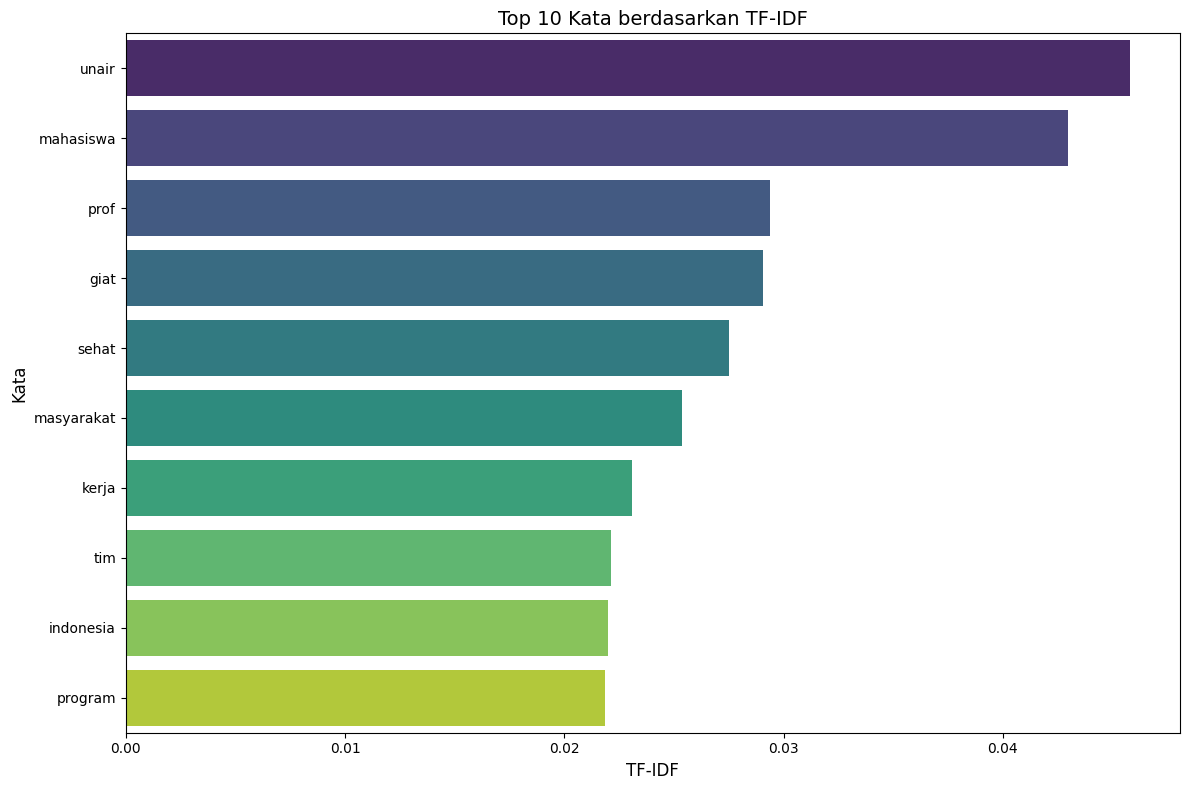

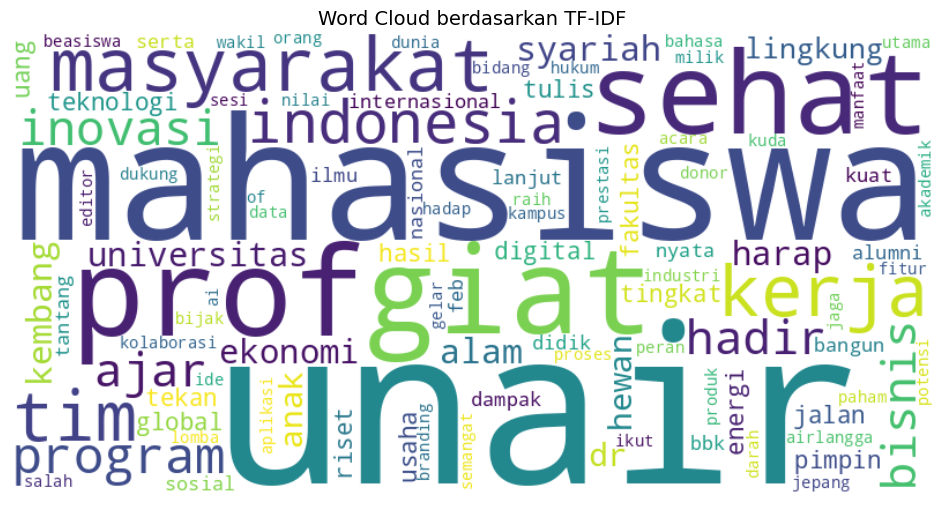

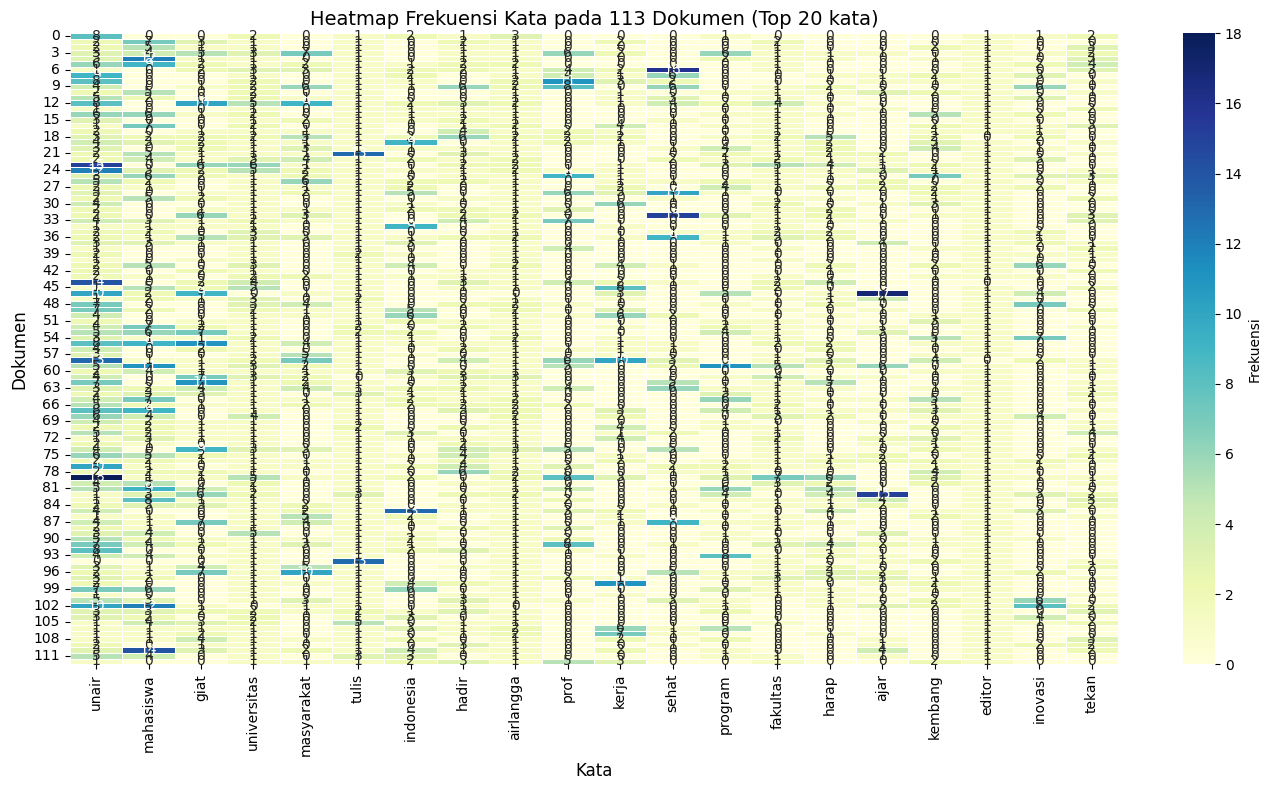

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer # Import CountVectorizer

text_docs = [' '.join(doc) for doc in df['Berita_preprocessed']]

#Buat vectorizer untuk TF-IDF
tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(text_docs)

#Ambil feature names (kata)
feature_names = tfidf_vectorizer.get_feature_names_out()

#Buat DataFrame untuk TF-IDF
tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=feature_names)
tfidf_df.index.name = 'Document'
tfidf_df.index = tfidf_df.index + 1

#Hitung IDF secara manual dari vectorizer
idf_values = dict(zip(feature_names, tfidf_vectorizer.idf_))
idf_df = pd.DataFrame(list(idf_values.items()), columns=["Word", "IDF"]).sort_values("IDF", ascending=False)

#Hitung TF (Term Frequency) rata-rata per kata (dari BoW CountVectorizer)
count_vectorizer = CountVectorizer()
X_counts = count_vectorizer.fit_transform(text_docs)
tf_df = pd.DataFrame(X_counts.toarray(), columns=count_vectorizer.get_feature_names_out())
tf_avg = tf_df.mean(axis=0).reset_index()
tf_avg.columns = ["Word", "TF"]

#Gabungkan TF, IDF, dan contoh nilai TF-IDF rata-rata
tfidf_avg = tfidf_df.mean(axis=0).reset_index()
tfidf_avg.columns = ["Word", "TF-IDF"]

summary_stats = tf_avg.merge(idf_df, on="Word").merge(tfidf_avg, on="Word")
summary_stats = summary_stats.sort_values("TF-IDF", ascending=False).head(10)

print("\n=== Top 10 Kata berdasarkan TF-IDF ===")
#Fix the printing format for to_string
print(summary_stats.to_string(index=False, formatters={"TF": lambda x: f"{x:.2f}", "IDF": lambda x: f"{x:.2f}", "TF-IDF": lambda x: f"{x:.2f}"}))


#Bar Plot TOP 10 TF-IDF
plt.figure(figsize=(12, 8))
sns.barplot(y="Word", x="TF-IDF", data=summary_stats, palette="viridis")
plt.title("Top 10 Kata berdasarkan TF-IDF", fontsize=14)
plt.xlabel("TF-IDF", fontsize=12)
plt.ylabel("Kata", fontsize=12)
plt.tight_layout()
plt.show()

from wordcloud import WordCloud

#Word Cloud berdasarkan TF-IDF rata-rata
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="viridis",
    max_words=100
).generate_from_frequencies(dict(zip(tfidf_avg["Word"], tfidf_avg["TF-IDF"])))

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud berdasarkan TF-IDF", fontsize=14)
plt.show()

#Heatmap Word Frequencies (Top Words)

# Pilih top N kata berdasarkan TF rata-rata
top_n = 20
top_words = tf_avg.sort_values("TF", ascending=False).head(top_n)["Word"]

# Ambil hanya kolom untuk kata-kata top
heatmap_data = tf_df[top_words]

plt.figure(figsize=(14, 8))
sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    cbar_kws={'label': 'Frekuensi'},
    linewidths=0.5,
    annot=True,        # Tambahkan angka di setiap sel
    fmt="d"            # Format angka: d = integer (karena frekuensi kata)
)
plt.title(f"Heatmap Frekuensi Kata pada {len(tf_df)} Dokumen (Top {top_n} kata)", fontsize=14)
plt.xlabel("Kata", fontsize=12)
plt.ylabel("Dokumen", fontsize=12)
plt.tight_layout()
plt.show()

POS Tagging dan NER

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/443M [00:00<?, ?B/s]

Some weights of the model checkpoint at cahya/bert-base-indonesian-NER were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


model.safetensors:   0%|          | 0.00/443M [00:00<?, ?B/s]

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.



DataFrame Hasil POS & NER:
                                                Text  \
0  [ika, unair, tegas, gelar, akademik, amanah, k...   
1  [goes, to, campus, inspirasi, personal, brandi...   
2  [cuankruk, ajak, mahasiswa, feb, unair, kuasa,...   
3  [wujud, kkn, bbk, bas, sdgs, lpmb, unair, sele...   
4  [banking, dpkka, unair, bekal, mahasiswa, lite...   

                                           POS_Words  \
0  [ , ika,  un, air,  tegas,  gelar,  akademik, ...   
1  [ go, es,  to,  camp, us,  inspirasi,  persona...   
2  [ c, uan, k, ruk,  ajak,  mahasiswa,  f, eb,  ...   
3  [ wujud,  k, kn,  b, bk,  bas,  sd, gs,  l, p,...   
4  [ banking,  d, pk, ka,  un, air,  bekal,  maha...   

                                            POS_Tags  \
0  [NNP, NNP, NNP, NNP, ADJ, NNO, NNO, NNO, NNO, ...   
1  [NNP, NNP, NNP, NNP, NNP, NNO, ADJ, NNP, NNO, ...   
2  [NNP, NNP, NNP, NNP, NNP, NNO, NNP, NNP, NNP, ...   
3  [NNO, NNP, NNP, NNO, NNO, NNP, NNP, NNP, NNP, ...   
4  [NNP, NNP, NNP,

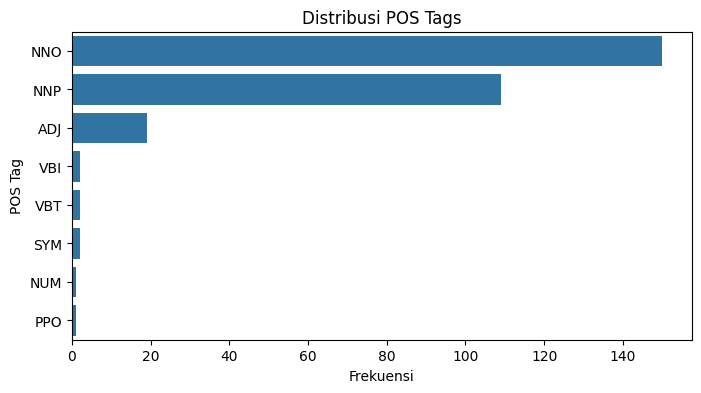

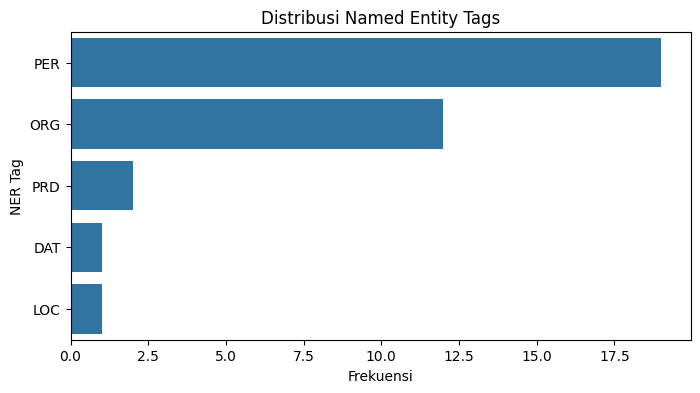

In [ ]:
import torch
import pandas as pd
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline
import matplotlib.pyplot as plt
import seaborn as sns


sample_text = df.loc[4, "Berita_preprocessed"]

#POS Tagging
pos_model_name = "w11wo/indonesian-roberta-base-posp-tagger"
pos_tokenizer = AutoTokenizer.from_pretrained(pos_model_name)
pos_model = AutoModelForTokenClassification.from_pretrained(pos_model_name)

pos_pipeline = pipeline(
    "token-classification",
    model=pos_model,
    tokenizer=pos_tokenizer,
    aggregation_strategy="simple"
)

# #Contoh uji POS Tagging
# print("Contoh Berita:", sample_text)
# print("\nHasil POS Tagging:")
# print(pos_pipeline(sample_text))

#Named Entity Recognition (NER)
ner_model_name = "cahya/bert-base-indonesian-NER"
ner_tokenizer = AutoTokenizer.from_pretrained(ner_model_name)
ner_model = AutoModelForTokenClassification.from_pretrained(ner_model_name)

ner_pipeline = pipeline(
    "ner",
    model=ner_model,
    tokenizer=ner_tokenizer,
    aggregation_strategy="simple"
)

#Simpan hasil POS & NER ke DataFrame
def analyze_text(text):
    pos_tags_raw = pos_pipeline(text)
    ner_tags_raw = ner_pipeline(text)

    pos_words = []
    pos_tags = []
    for item in pos_tags_raw:
        if isinstance(item, list):
            for sub_item in item:
                 if isinstance(sub_item, dict) and 'word' in sub_item and 'entity_group' in sub_item:
                    pos_words.append(sub_item['word'])
                    pos_tags.append(sub_item['entity_group'])
        elif isinstance(item, dict) and 'word' in item and 'entity_group' in item:
            pos_words.append(item['word'])
            pos_tags.append(item['entity_group'])


    ner_words = []
    ner_tags = []
    for item in ner_tags_raw:
        if isinstance(item, list):
            for sub_item in item:
                if isinstance(sub_item, dict) and 'word' in sub_item and 'entity_group' in sub_item:
                    ner_words.append(sub_item['word'])
                    ner_tags.append(sub_item['entity_group'])
        elif isinstance(item, dict) and 'word' in item and 'entity_group' in item:
            ner_words.append(item['word'])
            ner_tags.append(item['entity_group'])

    return {
        "Text": text,
        "POS_Words": pos_words,
        "POS_Tags": pos_tags,
        "NER_Words": ner_words,
        "NER_Tags": ner_tags
    }


results = df["Berita_preprocessed"].apply(analyze_text)
results_df = pd.DataFrame(results.tolist())

#Tampilkan hasil
print("\nDataFrame Hasil POS & NER:")
print(results_df.head())

#Simpan ke CSV
results_df.to_csv("hasil_POS_NER.csv", index=False)

sample_pos_words = results_df.loc[4, "POS_Words"]
sample_pos_tags = results_df.loc[4, "POS_Tags"]
sample_ner_words = results_df.loc[4, "NER_Words"]
sample_ner_tags = results_df.loc[4, "NER_Tags"]

pos_df = pd.DataFrame({'Token': sample_pos_words, 'POS': sample_pos_tags})
ner_df = pd.DataFrame({'Token': sample_ner_words, 'NER': sample_ner_tags})


print("=== Tabel POS ===")
print(pos_df.head())

print("\n=== Tabel NER ===")
print(ner_df.head())

#Visualisasi Frekuensi POS
plt.figure(figsize=(8,4))
sns.countplot(y="POS", data=pos_df, order=pos_df["POS"].value_counts().index)
plt.title("Distribusi POS Tags")
plt.xlabel("Frekuensi")
plt.ylabel("POS Tag")
plt.show()

#Visualisasi Frekuensi NER
plt.figure(figsize=(8,4))
sns.countplot(y="NER", data=ner_df, order=ner_df["NER"].value_counts().index)
plt.title("Distribusi Named Entity Tags")
plt.xlabel("Frekuensi")
plt.ylabel("NER Tag")
plt.show()

Model N-Gram

In [ ]:
import pandas as pd
from collections import Counter, defaultdict

bigrams = []
for tokens in df["Berita_preprocessed"]:
    bigrams.extend([(tokens[i], tokens[i+1]) for i in range(len(tokens)-1)])

bigram_counts = Counter(bigrams)

def predict_next_bigram(Query, top_k=5):
    Query = Query.lower()
    candidates = {w2: count for (w1, w2), count in bigram_counts.items() if w1 == Query}
    sorted_candidates = sorted(candidates.items(), key=lambda x: x[1], reverse=True)
    return [w for w, _ in sorted_candidates[:top_k]]


In [ ]:
#disini untuk input querynya
#@title Query
Query = "ftmm"  #@param {type:"string"}
predict_next_bigram(Query)

['unair', 'universitas', 'pasang', 'kolaborasi', 'peran']